In [45]:
!pip install pandas matplotlib seaborn scikit-learn numpy


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the California Housing dataset
df = pd.read_csv("Housing.csv")

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

#drop the duplicates
df = df.drop_duplicates()

# Convert categorical variables to numerical using one-hot encoding
yes_no_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
df[yes_no_cols] = df[yes_no_cols].replace({"yes": 1, "no": 0})
# Use dummies for the "furnishingstatus" column
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

# The target variable is price, which is a numerical variable, so this is a regression problem. The dataset contains 8 features, including both numerical and categorical variables.
y = df["price"]   # target variable
X = df[[
    "area",
    "bathrooms",
    "airconditioning",
    "stories",
    "parking",
    "bedrooms",
    "prefarea",
    "mainroad"
]]  # features


print(df.head())





Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3        1         0        0   
1  12250000  8960         4          4        4        1         0        0   
2  12250000  9960         3          2        2        1         0        1   
3  12215000  7500         4          2        2        1         0        1   
4  11410000  7420         4          1        2        1         1        1   

  hotwaterheating airconditioning  parking prefarea  \
0               0               1        2        1   
1               0               1        3        0   
2               0               0

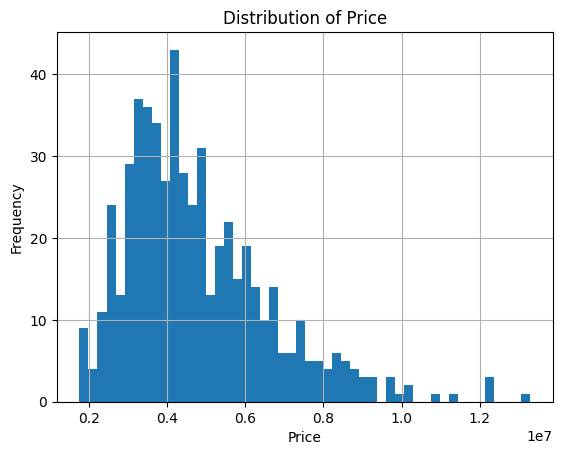

In [47]:
# Exploratory Data Analysis (EDA)

plt.figure()
df["price"].hist(bins=50)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

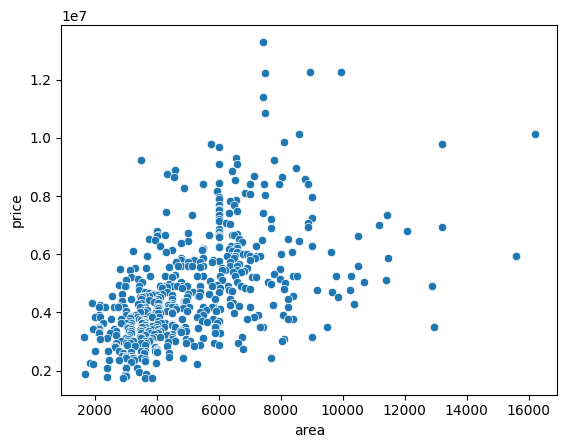

In [48]:
sns.scatterplot(x=df["area"], y=df["price"])
plt.show()

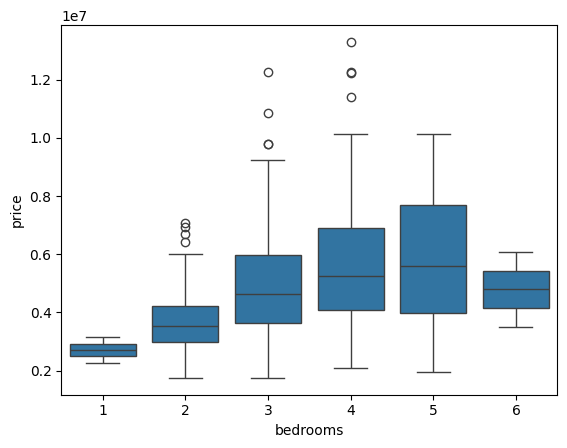

In [49]:
sns.boxplot(x=df["bedrooms"], y=df["price"])
plt.show()

In [50]:
# correlation with target
corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
print(corr)


price                              1.000000
area                               0.535997
bathrooms                          0.517545
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [51]:
# Import necessary libraries for model training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and train a Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Initialize and train a Random Forest Regressor model
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

# Make predictions on the test set for both models
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Calculate Root Mean Squared Error (RMSE) for Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
# Calculate Root Mean Squared Error (RMSE) for Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Print the RMSE values for comparison
print("Linear RMSE:", rmse_lr)
print("RF RMSE:", rmse_rf)

Linear RMSE: 1381117.6493139819
RF RMSE: 1451352.040174989


In [52]:
from sklearn.metrics import r2_score

# Evaluate regression models using the coefficient of determination (R²)
r2_lr = r2_score(y_test, y_pred_lr)
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear R²:", r2_lr)
print("RF R²:", r2_rf)

Linear R²: 0.6226215349128174
RF R²: 0.5832637312663457


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Create a three-class target based on price terciles
low = df["price"].quantile(0.33)
high = df["price"].quantile(0.67)

def categorize_price(price):
    if price < low:
        return 0  # low-priced homes
    elif price < high:
        return 1  # mid-priced homes
    else:
        return 2  # high-priced homes

df["price_category"] = df["price"].apply(categorize_price)

# Prepare classification features and target
y_class = df["price_category"]
X_class = df.drop(["price", "price_category"], axis=1)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Standardize numeric features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # use fit from train only

# Train Logistic Regression classifier
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train_scaled, y_train)

# Make predictions on test set
y_pred = lr_clf.predict(X_test_scaled)

# Evaluate classification performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("\nFull Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7339449541284404
F1 Score: 0.7412870803186639

Full Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.79        37
           1       0.50      0.61      0.55        28
           2       0.87      0.77      0.82        44

    accuracy                           0.73       109
   macro avg       0.73      0.72      0.72       109
weighted avg       0.75      0.73      0.74       109



In [54]:
'''Stage 1: Data Preprocessing & Initial Modeling
Dataset Requirements: Select a dataset with at least 12 features, including a minimum of two categorical and two numerical features. Define the target variable as either numerical (regression) or categorical (classification).
Preprocessing: Clean data (missing values, duplicates, errors) and perform EDA using visualizations to understand feature–target relationships.
Initial Modeling:
Regression: Select features via correlation, train multiple regression, evaluate using R² and RMSE.
Classification: Train a classifier (e.g., Logistic Regression), evaluate using Accuracy and F1-score.

Stage 2: Model Optimization & Comparative Analysis
Advanced Modeling: Implement two additional models.
Hyperparameter Tuning (if applicable): Use Grid/Randomized Search + k-fold cross-validation.
Feature Engineering: Apply feature selection, polynomial feature transformation, or regularization(optional).
Performance Comparison: Compare models using the two evaluation metrics with tables/visuals; identify the best model.'''


'Stage 1: Data Preprocessing & Initial Modeling\nDataset Requirements: Select a dataset with at least 12 features, including a minimum of two categorical and two numerical features. Define the target variable as either numerical (regression) or categorical (classification).\nPreprocessing: Clean data (missing values, duplicates, errors) and perform EDA using visualizations to understand feature–target relationships.\nInitial Modeling:\nRegression: Select features via correlation, train multiple regression, evaluate using R² and RMSE.\nClassification: Train a classifier (e.g., Logistic Regression), evaluate using Accuracy and F1-score.\n\nStage 2: Model Optimization & Comparative Analysis\nAdvanced Modeling: Implement two additional models.\nHyperparameter Tuning (if applicable): Use Grid/Randomized Search + k-fold cross-validation.\nFeature Engineering: Apply feature selection, polynomial feature transformation, or regularization(optional).\nPerformance Comparison: Compare models using

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Train a baseline Decision Tree classifier on the scaled training data
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

# Quick results
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Decision Tree F1:", f1_score(y_test, dt_pred, average="weighted"))
print()
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("KNN F1:", f1_score(y_test, knn_pred, average="weighted"))

Decision Tree Accuracy: 0.5963302752293578
Decision Tree F1: 0.6147185252185898

KNN Accuracy: 0.6788990825688074
KNN F1: 0.6860660790042004


In [56]:
from sklearn.model_selection import GridSearchCV

# --- Tune Decision Tree ---
dt_params = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), 
                       dt_params, cv=5, scoring="f1_weighted")
dt_grid.fit(X_train_scaled, y_train)

# --- Tune KNN ---
knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}
knn_grid = GridSearchCV(KNeighborsClassifier(), 
                        knn_params, cv=5, scoring="f1_weighted")
knn_grid.fit(X_train_scaled, y_train)

print("Best DT params:", dt_grid.best_params_)
print("Best KNN params:", knn_grid.best_params_)

Best DT params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
Best KNN params: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}


In [57]:
# Get predictions from the best tuned Decision Tree model on the scaled test set
dt_best_pred = dt_grid.best_estimator_.predict(X_test_scaled)

# Get predictions from the best tuned KNN model on the scaled test set
knn_best_pred = knn_grid.best_estimator_.predict(X_test_scaled)

# Print the accuracy and weighted F1 score for the tuned Decision Tree model
print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, dt_best_pred))
print("Tuned Decision Tree F1:", f1_score(y_test, dt_best_pred, average="weighted"))
print()

# Print the accuracy and weighted F1 score for the tuned KNN model
print("Tuned KNN Accuracy:", accuracy_score(y_test, knn_best_pred))
print("Tuned KNN F1:", f1_score(y_test, knn_best_pred, average="weighted"))

Tuned Decision Tree Accuracy: 0.6238532110091743
Tuned Decision Tree F1: 0.637831120048036

Tuned KNN Accuracy: 0.6605504587155964
Tuned KNN F1: 0.6687725002903263


                Model  Accuracy  F1 Score
  Logistic Regression  0.733945  0.741287
Decision Tree (tuned)  0.623853  0.637831
          KNN (tuned)  0.660550  0.668773


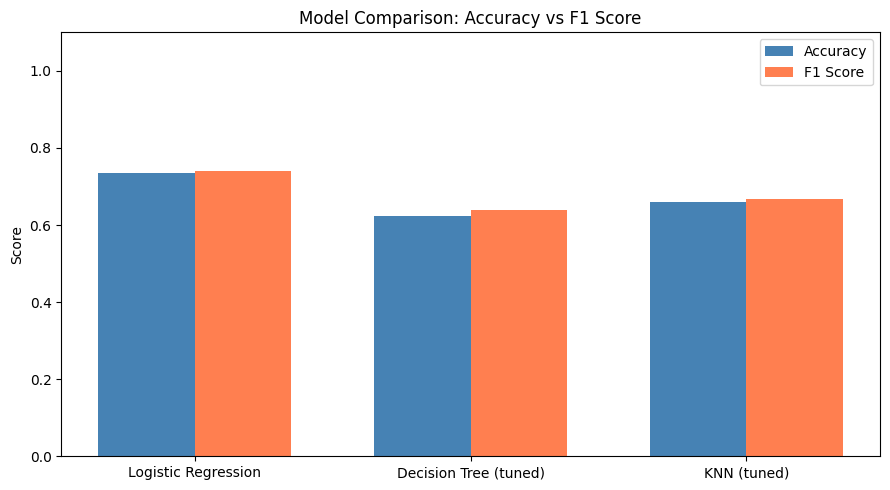


Best model: Logistic Regression (F1: 0.7413)


In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Create a dictionary to store model names and their performance metrics (Accuracy and F1 Score)
# Metrics are calculated using the test set predictions from Logistic Regression, tuned Decision Tree, and tuned KNN
results = {
    "Model": ["Logistic Regression", "Decision Tree (tuned)", "KNN (tuned)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),  # Accuracy for Logistic Regression
        accuracy_score(y_test, dt_best_pred),  # Accuracy for tuned Decision Tree
        accuracy_score(y_test, knn_best_pred)  # Accuracy for tuned KNN
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, average="weighted"),  # Weighted F1 Score for Logistic Regression
        f1_score(y_test, dt_best_pred, average="weighted"),  # Weighted F1 Score for tuned Decision Tree
        f1_score(y_test, knn_best_pred, average="weighted")  # Weighted F1 Score for tuned KNN
    ]
}

# Convert the results dictionary into a pandas DataFrame for easy tabular display
results_df = pd.DataFrame(results)
# Print the DataFrame as a string without the index for a clean table output
print(results_df.to_string(index=False))

# Prepare data for a bar chart comparing Accuracy and F1 Score across models
x = np.arange(len(results["Model"]))  # Create an array of indices for the x-axis positions
width = 0.35  # Set the width of each bar

# Create a figure and axis for the bar chart with specified size
fig, ax = plt.subplots(figsize=(9, 5))
# Plot Accuracy bars on the left side of each group
ax.bar(x - width/2, results["Accuracy"], width, label="Accuracy", color="steelblue")
# Plot F1 Score bars on the right side of each group
ax.bar(x + width/2, results["F1 Score"], width, label="F1 Score", color="coral")

# Set y-axis limits to ensure scores are visible (0 to 1.1 for percentages)
ax.set_ylim(0, 1.1)
# Set x-axis ticks at the model positions
ax.set_xticks(x)
# Label x-axis ticks with model names
ax.set_xticklabels(results["Model"])
# Label the y-axis
ax.set_ylabel("Score")
# Set the title of the chart
ax.set_title("Model Comparison: Accuracy vs F1 Score")
# Add a legend to distinguish Accuracy and F1 Score bars
ax.legend()
# Adjust layout to prevent clipping
plt.tight_layout()
# Display the plot
plt.show()

# Determine the best model based on the highest F1 Score
best_idx = results_df["F1 Score"].idxmax()  # Find the index of the maximum F1 Score
# Print the best model name and its F1 Score formatted to 4 decimal places
print(f"\nBest model: {results_df.loc[best_idx, 'Model']} "
      f"(F1: {results_df.loc[best_idx, 'F1 Score']:.4f})")

Tuned Decision Tree RMSE: 1790085.3869844268
Tuned Decision Tree R²: 0.3660379544625033
                Model         RMSE       R²
    Linear Regression 1.381118e+06 0.622622
        Random Forest 1.451352e+06 0.583264
Decision Tree (tuned) 1.790085e+06 0.366038


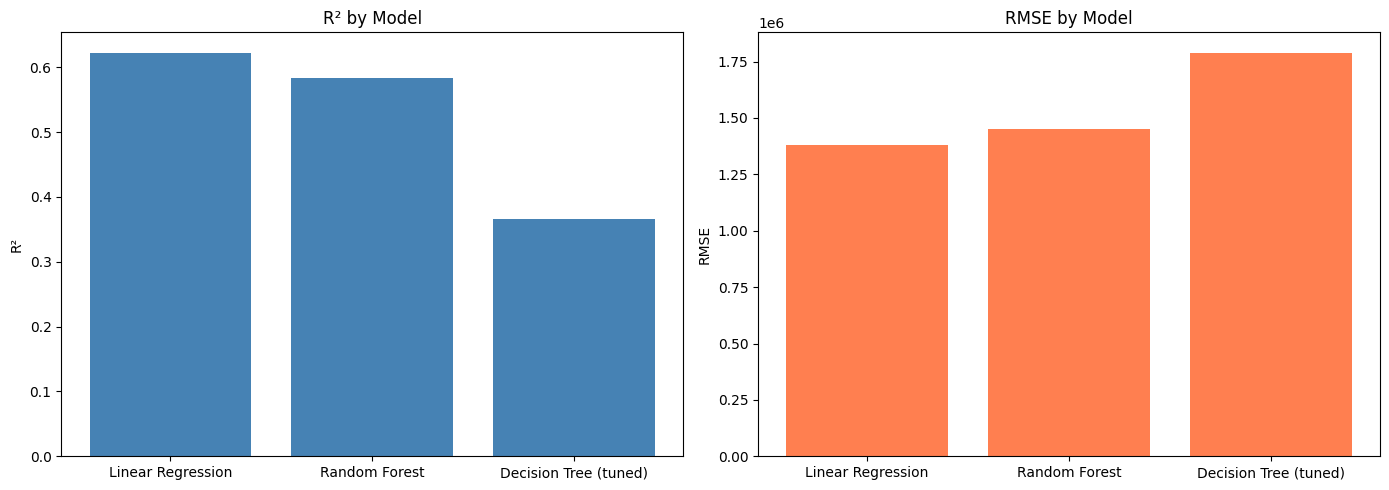

In [59]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
decisiontree_reg = DecisionTreeRegressor(random_state=0)
decisiontree_reg_params = {"max_depth": [3, 5, 10, None],"min_samples_split": [2, 5, 10]}
decisiontree_reg_grid = GridSearchCV(decisiontree_reg, decisiontree_reg_params, cv=5, scoring="r2")
decisiontree_reg_grid.fit(X_train, y_train)
y_pred_decisiontree = decisiontree_reg_grid.best_estimator_.predict(X_test)
rmse_decisiontree = np.sqrt(mean_squared_error(y_test, y_pred_decisiontree))
r2_dt = r2_score(y_test, y_pred_decisiontree)
print("Tuned Decision Tree RMSE:", rmse_decisiontree)
print("Tuned Decision Tree R²:", r2_dt)
reg_results = {
    "Model": ["Linear Regression", "Random Forest", "Decision Tree (tuned)"],
    "RMSE": [rmse_lr, rmse_rf, rmse_decisiontree],
    "R²": [r2_lr, r2_rf, r2_dt]
}

reg_df = pd.DataFrame(reg_results)
print(reg_df.to_string(index=False))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
models = reg_results["Model"]
ax1.bar(models, reg_results["R²"], color="steelblue")
ax1.set_title("R² by Model")
ax1.set_ylabel("R²")
ax2.bar(models, reg_results["RMSE"], color="coral")
ax2.set_title("RMSE by Model")
ax2.set_ylabel("RMSE")

plt.tight_layout()
plt.show()